# S4/S5 · AndinaLog 03B · Evidencia 1 · Excursiones térmicas

**Pregunta:** ¿Qué proporción de viajes presenta desviación térmica y cómo se distribuye por producto, categoría logística y tipo de camión?

Este notebook **solo lee** los Silver de IoT, Productos y Flota. Construye en memoria el dataset analítico, valida sus joins y realiza el EDA. No corrige ni sobrescribe los Silver. Las asociaciones observadas no prueban causas.

**Unidades:** IoT = una lectura; Productos = un producto; Flota = un camión. La unidad inicial del dataset analítico es una combinación única de `viaje_id`, `order_id`, `camion_id` y `producto_id`. Solo se llama *viaje* a esa unidad cuando las claves confirman que hay exactamente una combinación por `viaje_id`.

## 1 · Configuración y carga de los tres Silver

Ejecuta desde la raíz o una subcarpeta del proyecto. También puedes asignar rutas absolutas a `RUTAS_MANUALES`. En Colab, ajusta `RUTA_PROYECTO_DRIVE`. El notebook acepta las dos estructuras usadas por los notebooks de tratamiento (`S4/...` y `proyecto-integrador/...`).

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # auto, local o drive
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
RUTAS_MANUALES = {"iot": None, "productos": None, "flota": None}
ARCHIVOS = {
    "iot": "andinalog_iot_telemetry_silver.csv",
    "productos": "andinalog_productos_silver.csv",
    "flota": "andinalog_flota_silver.csv",
}
SUBRUTAS = {
    "iot": ["S4/andinalog_iot_telemetry/notebook2/salidas", "proyecto-integrador/andinalog_iot_telemetry/notebook2/salidas"],
    "productos": ["proyecto-integrador/andinalog_productos/notebook2/salidas", "S4/andinalog_productos/notebook2/salidas"],
    "flota": ["proyecto-integrador/andinalog_flota/notebook2/salidas", "S4/andinalog_flota/notebook2/salidas"],
}

def raices_posibles():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        return [Path(RUTA_PROYECTO_DRIVE)]
    if entorno == "local":
        return [Path.cwd(), *Path.cwd().parents]
    raise ValueError("ENTORNO debe ser auto, local o drive")

def encontrar_silver(nombre):
    manual = RUTAS_MANUALES[nombre]
    if manual is not None:
        ruta = Path(manual)
        if not ruta.is_file():
            raise FileNotFoundError(f"No existe {nombre}: {ruta}")
        return ruta
    for raiz in raices_posibles():
        for subruta in SUBRUTAS[nombre]:
            ruta = raiz / subruta / ARCHIVOS[nombre]
            if ruta.is_file():
                return ruta
    raise FileNotFoundError(f"No se encontró {ARCHIVOS[nombre]}. Indica su ruta en RUTAS_MANUALES['{nombre}'].")

rutas = {nombre: encontrar_silver(nombre) for nombre in ARCHIVOS}
for nombre, ruta in rutas.items():
    print(nombre, "→", ruta)

def leer_silver(ruta):
    return pd.read_csv(ruta, dtype="string", encoding="utf-8-sig", keep_default_na=False)

iot_raw, productos_raw, flota_raw = (leer_silver(rutas[n]) for n in ("iot", "productos", "flota"))

iot → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_iot_telemetry\notebook2\salidas\andinalog_iot_telemetry_silver.csv
productos → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_productos\notebook2\salidas\andinalog_productos_silver.csv
flota → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_flota\notebook2\salidas\andinalog_flota_silver.csv


## 2 · Contrato y validación de los Silver

Se comprueban columnas necesarias, vacíos en claves, tipos, rangos y unicidad de las dimensiones. Una falla detiene el análisis para no producir conclusiones con claves ambiguas. Las conversiones ocurren únicamente en memoria.

In [3]:
REQUERIDAS = {
    "iot": {"timestamp", "viaje_id", "order_id", "camion_id", "producto_id", "temperatura_cabina_c", "desviacion_termica_flag"},
    "productos": {"producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"},
    "flota": {"camion_id", "tipo_camion"},
}
fuentes = {"iot": iot_raw, "productos": productos_raw, "flota": flota_raw}
for nombre, tabla in fuentes.items():
    faltantes = REQUERIDAS[nombre] - set(tabla.columns)
    if faltantes or tabla.empty:
        raise ValueError(f"{nombre}: columnas faltantes {sorted(faltantes)} o Silver vacío")
    claves = {"iot": ["viaje_id", "order_id", "camion_id", "producto_id"],
              "productos": ["producto_id"], "flota": ["camion_id"]}[nombre]
    if tabla[claves].eq("").any().any() or tabla[claves].isna().any().any():
        raise ValueError(f"{nombre}: claves vacías")

if productos_raw["producto_id"].duplicated().any():
    raise ValueError("Productos no es una dimensión única por producto_id")
if flota_raw["camion_id"].duplicated().any():
    raise ValueError("Flota no es una dimensión única por camion_id")

iot = iot_raw.copy(deep=True)
productos = productos_raw.copy(deep=True)
flota = flota_raw.copy(deep=True)
iot["timestamp"] = pd.to_datetime(iot["timestamp"], errors="raise")
for col in ["temperatura_cabina_c", "desviacion_termica_flag"]:
    iot[col] = pd.to_numeric(iot[col], errors="raise")
for col in ["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]:
    productos[col] = pd.to_numeric(productos[col], errors="raise")
if iot[["timestamp", "temperatura_cabina_c", "desviacion_termica_flag"]].isna().any().any():
    raise ValueError("IoT contiene fechas, temperaturas o banderas nulas")
if not iot["desviacion_termica_flag"].isin([0, 1]).all():
    raise ValueError("desviacion_termica_flag debe ser 0/1")
if iot["temperatura_cabina_c"].lt(-273.15).any() or iot["temperatura_cabina_c"].eq(-999).any():
    raise ValueError("IoT contiene temperatura imposible o centinela -999")
if productos[["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]].isna().any().any():
    raise ValueError("Productos contiene parámetros térmicos nulos")
if productos["tolerancia_temperatura_c"].lt(0).any():
    raise ValueError("Productos contiene tolerancia negativa")
if iot.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("IoT contiene viaje_id + timestamp duplicados; revisar granularidad")

display(pd.DataFrame([{"fuente": n, "filas": len(t), "columnas": len(t.columns)} for n, t in fuentes.items()]))

,fuente,filas,columnas
0,iot,28425,10
1,productos,50,7
2,flota,28,4


## 3 · Granularidad y cobertura antes del join

La guía propone agregar IoT por viaje, orden, camión y producto. Antes se verifica si `viaje_id` identifica una sola combinación. Si no ocurre, el análisis por vehículo/producto usa **combinaciones**, y la tasa global por viaje se calcula aparte con `viaje_id` único.

In [4]:
CLAVE_UNIDAD = ["viaje_id", "order_id", "camion_id", "producto_id"]
combinaciones_por_viaje = iot[CLAVE_UNIDAD].drop_duplicates().groupby("viaje_id").size()
viajes_multicombinacion = int(combinaciones_por_viaje.gt(1).sum())
print("Viajes únicos:", iot["viaje_id"].nunique())
print("Combinaciones viaje-orden-camión-producto:", len(iot[CLAVE_UNIDAD].drop_duplicates()))
print("Viajes con más de una combinación:", viajes_multicombinacion)
if viajes_multicombinacion:
    print("Atención: las tasas por producto/camión tendrán combinaciones como denominador, no viajes únicos.")

cobertura = pd.DataFrame([
    {"dimensión": "Productos", "claves_IoT_sin_match": int((~iot["producto_id"].isin(productos["producto_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["producto_id"].isin(productos["producto_id"]), "producto_id"].nunique())},
    {"dimensión": "Flota", "claves_IoT_sin_match": int((~iot["camion_id"].isin(flota["camion_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["camion_id"].isin(flota["camion_id"]), "camion_id"].nunique())},
])
display(cobertura)
print("Lecturas por viaje (mín., mediana, máx.):", *iot.groupby("viaje_id").size().agg(["min", "median", "max"]).tolist())

Viajes únicos: 1200
Combinaciones viaje-orden-camión-producto: 1200
Viajes con más de una combinación: 0


,dimensión,claves_IoT_sin_match,claves_distintas_sin_match
0,Productos,4984,10
1,Flota,2389,2


Lecturas por viaje (mín., mediana, máx.): 21.0 24.0 24.0


## 4 · Agregación IoT y joins N:1

Se agrega IoT antes de calcular tasas por producto o camión. `n_desviaciones` cuenta lecturas marcadas; `tuvo_desviacion` indica si la combinación tuvo al menos una. Los joins `left` conservan las unidades de IoT y `validate="many_to_one"` impide multiplicaciones silenciosas.

In [5]:
unidad = iot.groupby(CLAVE_UNIDAD, as_index=False, dropna=False).agg(
    n_lecturas=("timestamp", "size"),
    temperatura_promedio_c=("temperatura_cabina_c", "mean"),
    temperatura_min_c=("temperatura_cabina_c", "min"),
    temperatura_max_c=("temperatura_cabina_c", "max"),
    n_desviaciones=("desviacion_termica_flag", "sum"),
)
unidad["tuvo_desviacion"] = unidad["n_desviaciones"].gt(0)
assert unidad["n_lecturas"].sum() == len(iot)
assert unidad["n_desviaciones"].sum() == iot["desviacion_termica_flag"].sum()

analitico = unidad.merge(
    productos[["producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]],
    on="producto_id", how="left", validate="many_to_one", indicator="match_producto"
).merge(
    flota[["camion_id", "tipo_camion"]],
    on="camion_id", how="left", validate="many_to_one", indicator="match_flota"
)
if len(analitico) != len(unidad) or analitico.duplicated(CLAVE_UNIDAD).any():
    raise ValueError("El join alteró la granularidad")
display(analitico[["match_producto", "match_flota"]].value_counts(dropna=False).rename("unidades").reset_index())
print("Unidades antes/después del join:", len(unidad), len(analitico))

,match_producto,match_flota,unidades
0,both,both,905
1,left_only,both,194
2,both,left_only,85
3,left_only,left_only,16
4,both,right_only,0
5,left_only,right_only,0
6,right_only,left_only,0
7,right_only,both,0
8,right_only,right_only,0


Unidades antes/después del join: 1200 1200


## 5 · Validación del dataset analítico

Una categoría o tipo de camión faltante por ausencia de match se muestra como **Sin correspondencia** en los resúmenes. No se interpreta como categoría real. Los valores no se imputan en los Silver.

In [6]:
analitico["categoria_eda"] = analitico["categoria_logistica"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["tipo_camion_eda"] = analitico["tipo_camion"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["exceso_sobre_tolerancia_c"] = (
    (analitico["temperatura_promedio_c"] - analitico["temperatura_conservacion_requerida_c"]).abs()
    - analitico["tolerancia_temperatura_c"]
)
validacion = pd.DataFrame([
    {"control": "Unidades analíticas", "resultado": len(analitico)},
    {"control": "Lecturas reconciliadas", "resultado": int(analitico["n_lecturas"].sum())},
    {"control": "Lecturas desviadas reconciliadas", "resultado": int(analitico["n_desviaciones"].sum())},
    {"control": "Unidades sin producto", "resultado": int(analitico["match_producto"].ne("both").sum())},
    {"control": "Unidades sin flota", "resultado": int(analitico["match_flota"].ne("both").sum())},
    {"control": "Claves duplicadas", "resultado": int(analitico.duplicated(CLAVE_UNIDAD).sum())},
    {"control": "Temperaturas promedio nulas", "resultado": int(analitico["temperatura_promedio_c"].isna().sum())},
])
display(validacion)
assert analitico["n_lecturas"].sum() == len(iot)
assert analitico["n_desviaciones"].sum() == iot["desviacion_termica_flag"].sum()
assert analitico["n_desviaciones"].le(analitico["n_lecturas"]).all()
assert analitico["n_lecturas"].gt(0).all()

,control,resultado
0,Unidades analíticas,1200
1,Lecturas reconciliadas,28425
2,Lecturas desviadas reconciliadas,936
3,Unidades sin producto,210
4,Unidades sin flota,101
5,Claves duplicadas,0
6,Temperaturas promedio nulas,0


## 6 · Preguntas analíticas y EDA

1. ¿Cuántos viajes únicos tuvieron alguna desviación?
2. ¿Qué porcentaje de las combinaciones viaje–orden–camión–producto tuvo desviación?
3. ¿Cómo varía esa tasa por categoría logística y tipo de camión, considerando el tamaño de cada grupo?
4. ¿Qué productos aparecen con más unidades afectadas y qué cobertura tienen los joins?

La temperatura promedio de una unidad resume sus lecturas; **no** sustituye la bandera por lectura ni demuestra que todas las lecturas hayan estado dentro o fuera del rango permitido.

In [7]:
viajes = iot.groupby("viaje_id", as_index=False).agg(
    n_lecturas=("timestamp", "size"),
    n_desviaciones=("desviacion_termica_flag", "sum"),
)
viajes["tuvo_desviacion"] = viajes["n_desviaciones"].gt(0)
resumen_general = pd.DataFrame([
    {"unidad": "Lectura", "total": len(iot), "con_desviacion": int(iot["desviacion_termica_flag"].sum()),
     "porcentaje": 100 * iot["desviacion_termica_flag"].mean()},
    {"unidad": "Viaje único", "total": len(viajes), "con_desviacion": int(viajes["tuvo_desviacion"].sum()),
     "porcentaje": 100 * viajes["tuvo_desviacion"].mean()},
    {"unidad": "Combinación viaje-orden-camión-producto", "total": len(analitico),
     "con_desviacion": int(analitico["tuvo_desviacion"].sum()),
     "porcentaje": 100 * analitico["tuvo_desviacion"].mean()},
])
display(resumen_general.round(2))
display(analitico[["n_lecturas", "temperatura_promedio_c", "temperatura_min_c", "temperatura_max_c", "n_desviaciones"]].describe().round(2))

,unidad,total,con_desviacion,porcentaje
0,Lectura,28425,936,3.29
1,Viaje único,1200,346,28.83
2,Combinación viaje-orden-camión-producto,1200,346,28.83


,n_lecturas,temperatura_promedio_c,temperatura_min_c,temperatura_max_c,n_desviaciones
count,1200.00,1200.0,1200.0,1200.0,1200.0
mean,23.69,8.34,5.63,11.43,0.78
std,0.55,13.96,13.23,14.6,1.61
min,21.00,-18.39,-21.63,-17.33,0.0
25%,23.00,3.91,2.15,5.29,0.0
50%,24.00,19.12,13.89,21.63,0.0
75%,24.00,20.03,16.55,23.6,1.0
max,24.00,21.81,18.97,29.69,7.0


In [8]:
def resumir_grupo(columnas):
    tabla = analitico.groupby(columnas, dropna=False, as_index=False).agg(
        n_unidades=("tuvo_desviacion", "size"),
        unidades_con_desviacion=("tuvo_desviacion", "sum"),
        lecturas=("n_lecturas", "sum"),
        lecturas_con_desviacion=("n_desviaciones", "sum"),
        temp_promedio_unidades_c=("temperatura_promedio_c", "mean"),
    )
    tabla["pct_unidades_con_desviacion"] = 100 * tabla["unidades_con_desviacion"] / tabla["n_unidades"]
    tabla["pct_lecturas_con_desviacion"] = 100 * tabla["lecturas_con_desviacion"] / tabla["lecturas"]
    return tabla.sort_values(["pct_unidades_con_desviacion", "n_unidades"], ascending=[False, False])

por_categoria = resumir_grupo(["categoria_eda"])
por_camion = resumir_grupo(["tipo_camion_eda"])
por_cruce = resumir_grupo(["categoria_eda", "tipo_camion_eda"])
por_producto = resumir_grupo(["producto_id", "categoria_eda"])
print("Por categoría logística")
display(por_categoria.round(2))
print("Por tipo de camión")
display(por_camion.round(2))
print("Cruce categoría × tipo de camión")
display(por_cruce.round(2))
print("Productos, ordenados por número de unidades afectadas")
display(por_producto.sort_values("unidades_con_desviacion", ascending=False).head(15).round(2))
assert por_categoria["n_unidades"].sum() == len(analitico)
assert por_camion["lecturas"].sum() == len(iot)

Por categoría logística


,categoria_eda,n_unidades,unidades_con_desviacion,lecturas,lecturas_con_desviacion,temp_promedio_unidades_c,pct_unidades_con_desviacion,pct_lecturas_con_desviacion
1,Fresco,305,121,7219,388,4.26,39.67,5.37
0,Congelado,189,72,4474,208,-17.73,38.1,4.65
3,Sin correspondencia,210,75,4984,208,10.01,35.71,4.17
2,Seco,496,78,11748,132,20.07,15.73,1.12


Por tipo de camión


,tipo_camion_eda,n_unidades,unidades_con_desviacion,lecturas,lecturas_con_desviacion,temp_promedio_unidades_c,pct_unidades_con_desviacion,pct_lecturas_con_desviacion
0,Refrigerado,792,254,18748,701,4.74,32.07,3.74
2,Sin correspondencia,101,29,2389,82,5.36,28.71,3.43
1,Seco,307,63,7288,153,18.59,20.52,2.1


Cruce categoría × tipo de camión


,categoria_eda,tipo_camion_eda,n_unidades,unidades_con_desviacion,lecturas,lecturas_con_desviacion,temp_promedio_unidades_c,pct_unidades_con_desviacion,pct_lecturas_con_desviacion
1,Congelado,Seco,9,8,214,30,-17.16,88.89,14.02
4,Fresco,Seco,8,7,191,36,5.14,87.5,18.85
2,Congelado,Sin correspondencia,21,10,500,26,-17.62,47.62,5.2
11,Sin correspondencia,Sin correspondencia,16,7,376,20,8.51,43.75,5.32
3,Fresco,Refrigerado,265,106,6273,323,4.24,40.0,5.15
9,Sin correspondencia,Refrigerado,141,56,3349,156,6.38,39.72,4.66
0,Congelado,Refrigerado,159,54,3760,152,-17.78,33.96,4.04
5,Fresco,Sin correspondencia,32,8,755,29,4.23,25.0,3.84
10,Sin correspondencia,Seco,53,12,1259,32,20.11,22.64,2.54
6,Seco,Refrigerado,227,38,5366,70,20.08,16.74,1.3


Productos, ordenados por número de unidades afectadas


,producto_id,categoria_eda,n_unidades,unidades_con_desviacion,lecturas,lecturas_con_desviacion,temp_promedio_unidades_c,pct_unidades_con_desviacion,pct_lecturas_con_desviacion
51,PROD-052,Fresco,27,14,638,39,4.26,51.85,6.11
33,PROD-034,Fresco,22,13,520,38,4.34,59.09,7.31
35,PROD-036,Sin correspondencia,25,13,595,30,4.23,52.0,5.04
53,PROD-054,Congelado,22,12,521,34,-17.62,54.55,6.53
7,PROD-008,Sin correspondencia,23,12,545,41,-17.48,52.17,7.52
55,PROD-056,Fresco,25,12,595,47,4.4,48.0,7.9
50,PROD-051,Congelado,27,12,642,47,-17.55,44.44,7.32
43,PROD-044,Fresco,21,10,499,33,4.29,47.62,6.61
15,PROD-016,Sin correspondencia,27,10,641,20,19.95,37.04,3.12
46,PROD-047,Fresco,19,9,448,41,4.55,47.37,9.15


## 7 · Visualizaciones

Las barras muestran tasas **y** el tamaño de cada grupo. Grupos pequeños pueden exhibir porcentajes extremos. El histograma muestra la distribución de promedios por unidad; para estudiar duración o severidad de las excursiones harían falta métricas temporales adicionales.

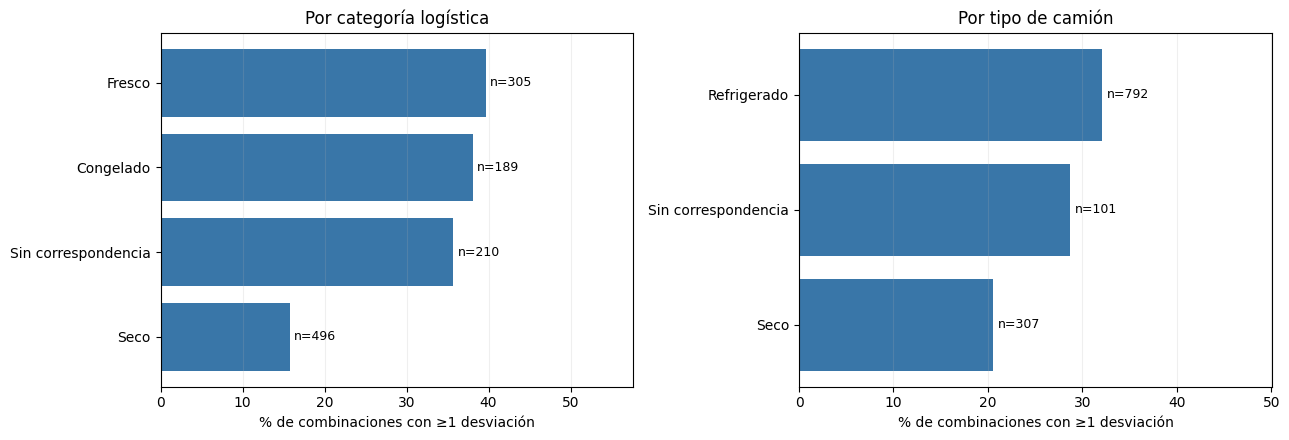

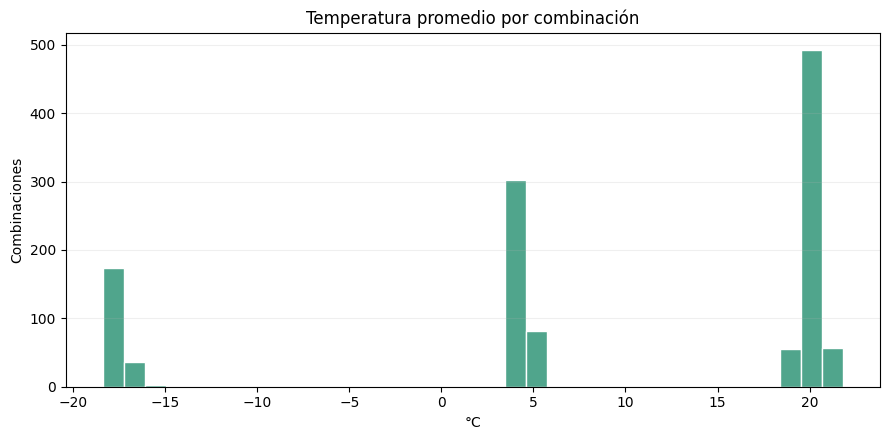

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, tabla, etiqueta in [(axes[0], por_categoria, "categoria_eda"), (axes[1], por_camion, "tipo_camion_eda")]:
    vista = tabla.sort_values("pct_unidades_con_desviacion")
    ax.barh(vista[etiqueta].astype(str), vista["pct_unidades_con_desviacion"], color="#3976A8")
    for y, (_, fila) in enumerate(vista.iterrows()):
        ax.text(fila["pct_unidades_con_desviacion"] + 0.5, y,
                f"n={int(fila['n_unidades'])}", va="center", fontsize=9)
    ax.set_xlim(0, max(10, min(115, float(vista["pct_unidades_con_desviacion"].max()) + 18)))
    ax.set_xlabel("% de combinaciones con ≥1 desviación")
    ax.grid(axis="x", alpha=0.2)
axes[0].set_title("Por categoría logística")
axes[1].set_title("Por tipo de camión")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(analitico["temperatura_promedio_c"].dropna(), bins=35, color="#50A58C", edgecolor="white")
ax.set(title="Temperatura promedio por combinación", xlabel="°C", ylabel="Combinaciones")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## 8 · Interpretación de la evidencia

Redacta al menos tres hallazgos tras ejecutar el notebook. En cada uno incluye **observación, cifra o gráfico, decisión operativa que podría orientar y límite de la inferencia**. Revisa en particular:

- La diferencia entre tasas por lectura, viaje único y combinación; sus denominadores responden preguntas distintas.
- Los grupos categoría × camión con tasas altas **y** suficiente número de unidades.
- Los productos asociados a desviaciones y las unidades sin correspondencia en Productos o Flota.
- Los viajes con varias combinaciones, antes de atribuir una excursión a un solo camión o producto.

La bandera `desviacion_termica_flag` se usa tal como fue preparada en Silver. Un exceso calculado con la **temperatura promedio** no reetiqueta lecturas individuales ni valida por sí solo la regla de esa bandera. Tampoco se puede inferir causalidad por tipo de camión sin controlar composición de productos, rutas y condiciones de operación.

In [10]:
print(f"ALCANCE: {len(iot):,} lecturas utilizables; {len(viajes):,} viajes únicos; {len(analitico):,} combinaciones analíticas.")
print(f"EXCURSIONES: {int(viajes['tuvo_desviacion'].sum()):,} viajes únicos ({100*viajes['tuvo_desviacion'].mean():.2f} %) y "
      f"{int(analitico['tuvo_desviacion'].sum()):,} combinaciones ({100*analitico['tuvo_desviacion'].mean():.2f} %) con al menos una lectura marcada.")
print(f"INTEGRIDAD: {viajes_multicombinacion:,} viajes con varias combinaciones; "
      f"{int(analitico['match_producto'].ne('both').sum()):,} combinaciones sin producto y "
      f"{int(analitico['match_flota'].ne('both').sum()):,} sin camión en Flota.")
print("LÍMITE: asociaciones descriptivas; faltan controles operativos para atribuir causas.")
print("Validaciones correctas. Los Silver no se modificaron.")

ALCANCE: 28,425 lecturas utilizables; 1,200 viajes únicos; 1,200 combinaciones analíticas.
EXCURSIONES: 346 viajes únicos (28.83 %) y 346 combinaciones (28.83 %) con al menos una lectura marcada.
INTEGRIDAD: 0 viajes con varias combinaciones; 210 combinaciones sin producto y 101 sin camión en Flota.
LÍMITE: asociaciones descriptivas; faltan controles operativos para atribuir causas.
Validaciones correctas. Los Silver no se modificaron.
